In [1]:
from pathlib import Path

import fastf1
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

# 1. Setup local cache directory
BASE_DIR = Path.cwd().parent
CACHE_DIR = BASE_DIR / "data" / "raw" / "fastf1_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
fastf1.Cache.enable_cache(CACHE_DIR)

- Current directory when running code in Jupyter is the directory that the running file is in (in this case, notebooks). Hence, some modification is needed. (current directory when running code in python is literally the current directory you're in)
- Path().resolve().parent
    - Path() creates a path object representing the current directory.
    - resolve() creates an absolute path to the current directory.
    - parent() goes one level above in the path.



In [2]:
# 2. Load 2024 Bahrain Grand Prix Race Session
# Year: 2024, Grand Prix: 'Bahrain', Session: 'R' (Race)
session = fastf1.get_session(2024, "Bahrain", "R")
session.load(telemetry=False, weather=True)

session

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']


2024 Season Round 1: Bahrain Grand Prix - Race

In [3]:
# 3. Extract laps dataframe
laps = session.laps
laps.head(5)

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 01:01:37.489000,VER,1,0 days 00:01:37.284000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:41.266000,...,False,Red Bull Racing,0 days 00:59:59.911000,NaT,12,1.0,False,,False,False
1,0 days 01:03:13.785000,VER,1,0 days 00:01:36.296000,2.0,1.0,NaT,NaT,0 days 00:00:30.916000,0 days 00:00:41.661000,...,False,Red Bull Racing,0 days 01:01:37.489000,NaT,1,1.0,False,,False,True
2,0 days 01:04:50.538000,VER,1,0 days 00:01:36.753000,3.0,1.0,NaT,NaT,0 days 00:00:30.999000,0 days 00:00:41.966000,...,False,Red Bull Racing,0 days 01:03:13.785000,NaT,1,1.0,False,,False,True
3,0 days 01:06:27.185000,VER,1,0 days 00:01:36.647000,4.0,1.0,NaT,NaT,0 days 00:00:30.931000,0 days 00:00:41.892000,...,False,Red Bull Racing,0 days 01:04:50.538000,NaT,1,1.0,False,,False,True
4,0 days 01:08:04.358000,VER,1,0 days 00:01:37.173000,5.0,1.0,NaT,NaT,0 days 00:00:31.255000,0 days 00:00:42.056000,...,False,Red Bull Racing,0 days 01:06:27.185000,NaT,1,1.0,False,,False,True


In [4]:
# 4. Convert Pandas df into Polars df
# Polars allow high-performance transformations
laps_pl = pl.from_pandas(laps)
laps_pl.schema

Schema([('Time', Duration(time_unit='ns')),
        ('Driver', String),
        ('DriverNumber', String),
        ('LapTime', Duration(time_unit='ns')),
        ('LapNumber', Float64),
        ('Stint', Float64),
        ('PitOutTime', Duration(time_unit='ns')),
        ('PitInTime', Duration(time_unit='ns')),
        ('Sector1Time', Duration(time_unit='ns')),
        ('Sector2Time', Duration(time_unit='ns')),
        ('Sector3Time', Duration(time_unit='ns')),
        ('Sector1SessionTime', Duration(time_unit='ns')),
        ('Sector2SessionTime', Duration(time_unit='ns')),
        ('Sector3SessionTime', Duration(time_unit='ns')),
        ('SpeedI1', Float64),
        ('SpeedI2', Float64),
        ('SpeedFL', Float64),
        ('SpeedST', Float64),
        ('IsPersonalBest', Boolean),
        ('Compound', String),
        ('TyreLife', Float64),
        ('FreshTyre', Boolean),
        ('Team', String),
        ('LapStartTime', Duration(time_unit='ns')),
        ('LapStartDate', Datetime

In [5]:
laps_pl.filter(pl.col("PitInTime").is_not_null())

Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
duration[ns],str,str,duration[ns],f64,f64,duration[ns],duration[ns],duration[ns],duration[ns],duration[ns],duration[ns],duration[ns],duration[ns],f64,f64,f64,f64,bool,str,f64,bool,str,duration[ns],datetime[ns],str,f64,bool,str,bool,bool
1h 27m 31s 964ms,"""VER""","""1""",1m 39s 896ms,17.0,1.0,null,1h 27m 30s 291ms,31s 6ms,42s 60ms,26s 830ms,1h 26m 23s 95ms,1h 27m 5s 155ms,1h 27m 31s 985ms,232.0,262.0,null,293.0,false,"""SOFT""",20.0,false,"""Red Bull Racing""",1h 25m 52s 68ms,null,"""1""",1.0,false,"""""",false,false
1h 59m 49s 491ms,"""VER""","""1""",1m 39s 234ms,37.0,2.0,null,1h 59m 47s 796ms,30s 877ms,41s 634ms,26s 723ms,1h 58m 41s 155ms,1h 59m 22s 789ms,1h 59m 49s 512ms,233.0,264.0,null,297.0,false,"""HARD""",20.0,true,"""Red Bull Racing""",1h 58m 10s 257ms,null,"""1""",1.0,false,"""""",false,false
1h 19m 36s 683ms,"""PER""","""11""",1m 40s 277ms,12.0,1.0,null,1h 19m 34s 991ms,30s 891ms,42s 506ms,26s 880ms,1h 18m 27s 319ms,1h 19m 9s 825ms,1h 19m 36s 705ms,228.0,257.0,null,312.0,false,"""SOFT""",15.0,false,"""Red Bull Racing""",1h 17m 56s 406ms,null,"""1""",3.0,false,"""""",false,false
1h 58m 31s 852ms,"""PER""","""11""",1m 39s 365ms,36.0,2.0,null,1h 58m 30s 216ms,31s 14ms,41s 781ms,26s 570ms,1h 57m 23s 523ms,1h 58m 5s 304ms,1h 58m 31s 874ms,234.0,264.0,null,299.0,false,"""HARD""",24.0,true,"""Red Bull Racing""",1h 56m 52s 487ms,null,"""1""",2.0,false,"""""",false,false
1h 22m 52s 561ms,"""SAI""","""55""",1m 39s 753ms,14.0,1.0,null,1h 22m 50s 807ms,31s 11ms,42s 119ms,26s 623ms,1h 21m 43s 870ms,1h 22m 25s 989ms,1h 22m 52s 612ms,235.0,258.0,null,298.0,false,"""SOFT""",17.0,false,"""Ferrari""",1h 21m 12s 808ms,null,"""1""",2.0,false,"""""",false,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1h 20m 2s 264ms,"""BOT""","""77""",1m 43s 145ms,12.0,1.0,null,1h 20m 495ms,31s 822ms,43s 874ms,27s 449ms,1h 18m 50s 957ms,1h 19m 34s 831ms,1h 20m 2s 280ms,234.0,250.0,null,303.0,false,"""SOFT""",12.0,true,"""Kick Sauber""",1h 18m 19s 119ms,null,"""1""",14.0,false,"""""",false,false
1h 49m 51s 985ms,"""BOT""","""77""",1m 41s 252ms,30.0,2.0,null,1h 49m 50s 207ms,31s 469ms,42s 763ms,27s 20ms,1h 48m 42s 218ms,1h 49m 24s 981ms,1h 49m 52s 1ms,233.0,254.0,null,300.0,false,"""HARD""",18.0,true,"""Kick Sauber""",1h 48m 10s 733ms,null,"""1""",16.0,false,"""""",false,false
1h 17m 39s 304ms,"""SAR""","""2""",null,10.0,1.0,null,1h 17m 37s 577ms,1m 23s 300ms,46s 732ms,31s 828ms,1h 16m 20s 849ms,1h 17m 7s 500ms,1h 17m 39s 505ms,208.0,195.0,null,293.0,false,"""SOFT""",10.0,true,"""Williams""",1h 14m 57s 453ms,null,"""12""",20.0,false,"""""",false,false


In [6]:
laps_pl.describe()

statistic,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
str,str,str,str,str,f64,f64,str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,str,f64,f64,str,str,str,str,f64,f64,str,f64,f64
"""count""","""1129""","""1129""","""1129""","""1127""",1129.0,1129.0,"""43""","""43""","""1108""","""1129""","""1129""","""1107""","""1129""","""1129""",1129.0,1129.0,1086.0,1129.0,1129.0,"""1129""",1129.0,1129.0,"""1129""","""1129""","""0""","""1129""",1129.0,1129.0,"""1129""",1129.0,1129.0
"""null_count""","""0""","""0""","""0""","""2""",0.0,0.0,"""1086""","""1086""","""21""","""0""","""0""","""22""","""0""","""0""",0.0,0.0,43.0,0.0,0.0,"""0""",0.0,0.0,"""0""","""0""","""1129""","""0""",0.0,0.0,"""0""",0.0,0.0
"""mean""","""1:47:20.629991""",null,null,"""0:01:38.004108""",28.728078,2.260407,"""1:38:54.520720""","""1:38:27.897651""","""0:00:31.819007""","""0:00:42.132447""","""0:00:24.030199""","""1:47:02.644366""","""1:46:56.622501""","""1:47:20.653046""",232.797166,254.411869,280.732044,297.123118,0.112489,null,10.705934,0.871568,null,"""1:45:42.500110""",null,null,10.447298,0.017715,null,0.0,0.906997
"""std""",null,null,null,null,16.305688,0.82591,null,null,null,null,null,null,null,null,3.896779,7.563647,3.479105,19.297776,null,null,6.277025,null,null,null,null,null,5.764214,null,null,null,null
"""min""","""1:01:37.489000""","""ALB""","""1""","""0:01:32.608000""",1.0,1.0,"""1:02:28.664000""","""1:01:52.101000""","""0:00:29.741000""","""0:00:39.916000""","""0:00:22.951000""","""1:02:08.426000""","""1:01:13.987000""","""1:01:37.669000""",185.0,195.0,244.0,186.0,0.0,"""HARD""",1.0,0.0,"""Alpine""","""0:59:59.911000""",null,"""1""",1.0,0.0,"""""",0.0,0.0
"""25%""","""1:24:48.203000""",null,null,"""0:01:36.133000""",15.0,2.0,"""1:20:26.625000""","""1:19:56.823000""","""0:00:30.708000""","""0:00:41.635000""","""0:00:23.680000""","""1:24:10.878000""","""1:24:22.515000""","""1:24:48.228000""",231.0,250.0,279.0,295.0,null,null,6.0,null,null,"""1:23:07.711000""",null,null,5.0,null,null,null,null
"""50%""","""1:47:28.529000""",null,null,"""0:01:37.046000""",29.0,2.0,"""1:45:07.900000""","""1:44:43.480000""","""0:00:30.956000""","""0:00:42.107000""","""0:00:23.907000""","""1:47:01.687000""","""1:47:04.550000""","""1:47:28.552000""",233.0,255.0,281.0,299.0,null,null,10.0,null,null,"""1:45:51.488000""",null,null,10.0,null,null,null,null
"""75%""","""2:10:29.778000""",null,null,"""0:01:38.152000""",43.0,3.0,"""1:56:03.352000""","""1:55:38.558000""","""0:00:31.168000""","""0:00:42.630000""","""0:00:24.198000""","""2:09:54.143000""","""2:10:06.037000""","""2:10:29.794000""",235.0,260.0,282.0,303.0,null,null,15.0,null,null,"""2:08:53.404000""",null,null,15.0,null,null,null,null
"""max""","""2:33:18.163000""","""ZHO""","""81""","""0:02:12.438000""",57.0,4.0,"""2:11:38.724000""","""2:11:13.617000""","""0:01:23.300000""","""0:00:46.732000""","""0:00:31.828000""","""2:32:11.848000""","""2:32:54.085000""","""2:33:18.189000""",241.0,272.0,293.0,332.0,1.0,"""SOFT""",30.0,1.0,"""Williams""","""2:31:40.828000""",null,"""21""",20.0,1.0,"""TRACK LIMITS AT TURN 4 LAP 56 """,0.0,1.0


In [7]:
# 4. Convert LapTime from timedelta object to seconds 
laps_pl = laps_pl.with_columns(
    (pl.col("LapTime").dt.total_milliseconds() / 1000).alias("LapTimeSeconds")
)

# convert to milliseconds instead of seconds because pl will round it up if convert seconds
laps_pl.schema

Schema([('Time', Duration(time_unit='ns')),
        ('Driver', String),
        ('DriverNumber', String),
        ('LapTime', Duration(time_unit='ns')),
        ('LapNumber', Float64),
        ('Stint', Float64),
        ('PitOutTime', Duration(time_unit='ns')),
        ('PitInTime', Duration(time_unit='ns')),
        ('Sector1Time', Duration(time_unit='ns')),
        ('Sector2Time', Duration(time_unit='ns')),
        ('Sector3Time', Duration(time_unit='ns')),
        ('Sector1SessionTime', Duration(time_unit='ns')),
        ('Sector2SessionTime', Duration(time_unit='ns')),
        ('Sector3SessionTime', Duration(time_unit='ns')),
        ('SpeedI1', Float64),
        ('SpeedI2', Float64),
        ('SpeedFL', Float64),
        ('SpeedST', Float64),
        ('IsPersonalBest', Boolean),
        ('Compound', String),
        ('TyreLife', Float64),
        ('FreshTyre', Boolean),
        ('Team', String),
        ('LapStartTime', Duration(time_unit='ns')),
        ('LapStartDate', Datetime

In [8]:
laps_pl.select(pl.col(c).null_count() for c in ["LapTimeSeconds", "Compound", "TyreLife", "TrackStatus", "PitInTime", "PitOutTime"])

LapTimeSeconds,Compound,TyreLife,TrackStatus,PitInTime,PitOutTime
u32,u32,u32,u32,u32,u32
2,0,0,0,1086,1086


In [9]:
laps_pl.filter(pl.col("LapTimeSeconds").is_null())

Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,LapTimeSeconds
duration[ns],str,str,duration[ns],f64,f64,duration[ns],duration[ns],duration[ns],duration[ns],duration[ns],duration[ns],duration[ns],duration[ns],f64,f64,f64,f64,bool,str,f64,bool,str,duration[ns],datetime[ns],str,f64,bool,str,bool,bool,f64
1h 52m 42s 259ms,"""BOT""","""77""",null,31.0,3.0,1h 51m 5s 158ms,null,null,42s 630ms,23s 793ms,null,1h 52m 18s 626ms,1h 52m 42s 493ms,231.0,252.0,280.0,186.0,false,"""HARD""",1.0,true,"""Kick Sauber""",1h 49m 51s 985ms,null,"""1""",19.0,false,"""""",false,false,null
1h 17m 39s 304ms,"""SAR""","""2""",null,10.0,1.0,null,1h 17m 37s 577ms,1m 23s 300ms,46s 732ms,31s 828ms,1h 16m 20s 849ms,1h 17m 7s 500ms,1h 17m 39s 505ms,208.0,195.0,null,293.0,false,"""SOFT""",10.0,true,"""Williams""",1h 14m 57s 453ms,null,"""12""",20.0,false,"""""",false,false,null


In [10]:
laps_pl.select("Compound").unique()

Compound
str
"""HARD"""
"""SOFT"""


In [11]:
track_status_analysis = (
    laps_pl
    .filter(pl.col("TrackStatus").is_not_null())
    .group_by("TrackStatus")
    .agg([
        pl.count().alias("total_laps"),
        pl.col("LapTimeSeconds").mean().alias("mean_lap_time"),
        pl.col("LapTimeSeconds").min().alias("fastest_lap_time"),
        pl.col("LapTimeSeconds").max().alias("slowest_lap_time")
    ])
    .sort("total_laps", descending=True)
)

track_status_analysis

C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_24516\1056981377.py:6: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("total_laps"),


TrackStatus,total_laps,mean_lap_time,fastest_lap_time,slowest_lap_time
str,u32,f64,f64,f64
"""1""",1087,97.849517,92.608,132.438
"""12""",40,102.323051,96.96,119.328
"""21""",2,97.7275,97.085,98.37


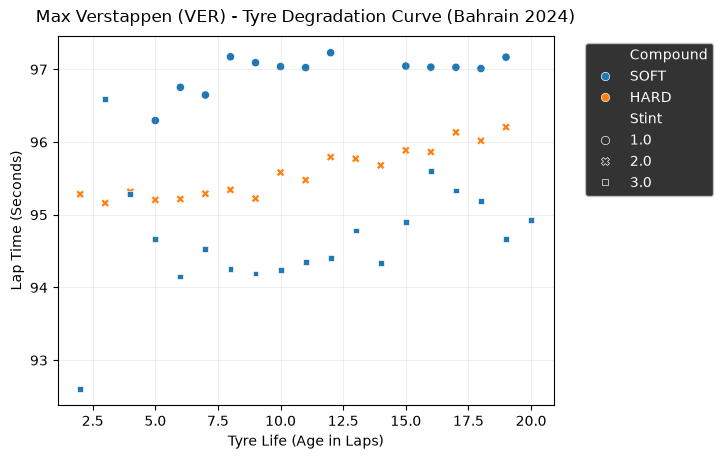

In [12]:
ver_laps = laps_pl.filter(
    (pl.col("Driver") == "VER") &
    (pl.col("TrackStatus") == "1") &
    (pl.col("LapTimeSeconds").is_not_null()) &
    (pl.col("PitInTime").is_null()) &
    (pl.col("PitOutTime").is_null())
)

ver_pd = ver_laps.to_pandas(use_pyarrow_extension_array=True)   # So can use for plotting

plt.figure()
sns.scatterplot(
    data=ver_pd,
    x="TyreLife",
    y="LapTimeSeconds",
    hue="Compound",
    style="Stint"
)

plt.style.use("dark_background")
plt.title("Max Verstappen (VER) - Tyre Degradation Curve (Bahrain 2024)", pad=10)
plt.xlabel("Tyre Life (Age in Laps)")
plt.ylabel("Lap Time (Seconds)")
plt.grid(True, alpha = 0.2)
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.show()

1. Fuel Weight vs. Tyre Wear (The Opposing Forces): An F1 car starts the race with roughly $110\text{ kg}$ of fuel. Every $10\text{ kg}$ of fuel burned makes the car about $0.3\text{ seconds}$ faster per lap. This means as the race progresses, the car gets significantly lighter and faster naturally.
2. Stint Grouping: Because fuel burns continuously, Stint 3 is naturally faster than Stint 1. The upward slope within a stint is tyre degradation, while the downward step between stints is fuel load dropping. If we don't account for fuel burn or total race lap number in our features, our model will get completely confused!
3. Compound Variability: Soft tyres deliver initial speed but degrade quickly and unpredictably, while Hard tyres provide a steady, durable baseline pace.

In [14]:
DATA_PATH = BASE_DIR / "data" / "processed" / "features_v1.parquet"

df = pl.read_parquet(DATA_PATH)
df.head(5)

Year,EventName,Driver,LapNumber,LapTimeSeconds,Compound,TyreLife,FreshTyre,Stint,TrackStatus,PitInTime,PitOutTime,Team,TrackTemp,AirTemp,prev_lap_time,rolling_3lap_mean,compound_code,is_fresh_tyre
i32,str,str,i32,f64,str,i32,bool,i32,str,str,str,str,f64,f64,f64,f64,i32,i32
2023,"""Bahrain""","""ALB""",4,99.761,"""SOFT""",4,true,1,"""1""",null,null,"""Williams""",null,null,100.143,100.143,1,1
2023,"""Bahrain""","""ALB""",5,100.606,"""SOFT""",5,true,1,"""1""",null,null,"""Williams""",null,null,99.761,99.952,1,1
2023,"""Bahrain""","""ALB""",6,100.744,"""SOFT""",6,true,1,"""1""",null,null,"""Williams""",null,null,100.606,100.17,1,1
2023,"""Bahrain""","""ALB""",7,100.646,"""SOFT""",7,true,1,"""1""",null,null,"""Williams""",null,null,100.744,100.370333,1,1
2023,"""Bahrain""","""ALB""",8,100.918,"""SOFT""",8,true,1,"""1""",null,null,"""Williams""",null,null,100.646,100.665333,1,1
